```
Hiểu:
- Padding là gì
- Tại sao cần Padding
- Output bị giảm kích thước như thế nào
- Zero Padding hoạt động ra sao
- Padding ảnh hưởng tới Output Shape như thế nào
```

```
No Padding

28x28
 ↓
26x26
 ↓
24x24
 ↓
22x22

Feature Map càng ngày càng nhỏ
```

```
Padding

28x28
 ↓
28x28
 ↓
28x28
 ↓
28x28
```

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.convolution import Convolution2D
from src.utils import (
    load_image,
    show_image
)

In [2]:
print("=" * 60)
print("CNN FROM SCRATCH")
print("03 - PADDING")
print("=" * 60)

CNN FROM SCRATCH
03 - PADDING


In [3]:
print("""
Without Padding

Input:
5x5

Kernel:
3x3

Output:
3x3

Every convolution reduces
the spatial size.

After many layers
information at image borders
is gradually lost.
""")


Without Padding

Input:
5x5

Kernel:
3x3

Output:
3x3

Every convolution reduces
the spatial size.

After many layers
information at image borders
is gradually lost.



Part 1 - No Padding Example

In [4]:
image = np.arange(25).reshape(5,5)

print(image)

[[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]
 [15 16 17 18 19]
 [20 21 22 23 24]]


In [5]:
kernel_size = 3
padding = 0
stride = 1

H = image.shape[0]
W = image.shape[1]

H_out = (
    (H - kernel_size + 2*padding)
    // stride
) + 1

W_out = (
    (W - kernel_size + 2*padding)
    // stride
) + 1

print("Input Shape :", image.shape)
print("Output Shape:", (H_out, W_out))

Input Shape : (5, 5)
Output Shape: (3, 3)


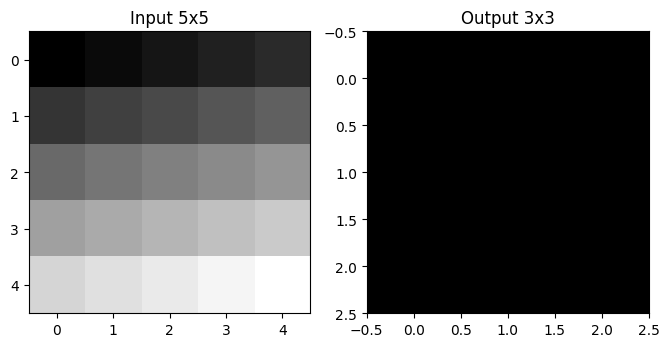

In [6]:
fig, ax = plt.subplots(
    1,
    2,
    figsize=(8,4)
)

ax[0].imshow(
    image,
    cmap="gray"
)

ax[0].set_title(
    "Input 5x5"
)

ax[1].imshow(
    np.zeros((3,3)),
    cmap="gray"
)

ax[1].set_title(
    "Output 3x3"
)

plt.show()

Part 2 - Zero Padding

In [7]:
image = np.array(
[
    [1,2,3],
    [4,5,6],
    [7,8,9]
]
)

print(image)

[[1 2 3]
 [4 5 6]
 [7 8 9]]


In [8]:
padded = np.pad(
    image,
    pad_width=1,
    mode="constant",
    constant_values=0
)

print(padded)

[[0 0 0 0 0]
 [0 1 2 3 0]
 [0 4 5 6 0]
 [0 7 8 9 0]
 [0 0 0 0 0]]


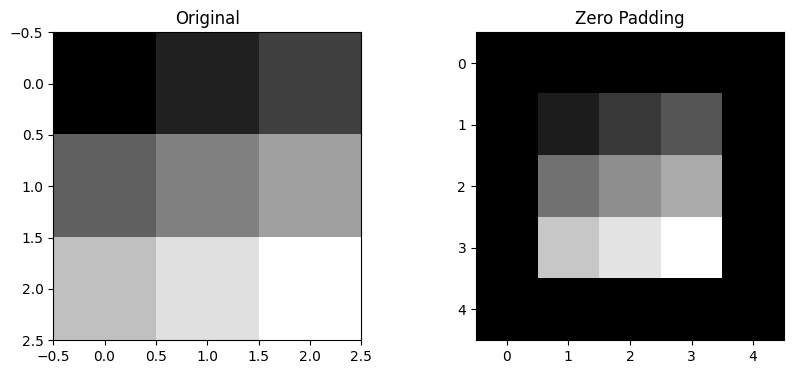

In [9]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)

plt.imshow(
    image,
    cmap="gray"
)

plt.title(
    "Original"
)

plt.subplot(1,2,2)

plt.imshow(
    padded,
    cmap="gray"
)

plt.title(
    "Zero Padding"
)

plt.show()

Part 3 - Padding Formula

In [10]:
print("""
Output Shape Formula

Hout =
((H-K+2P)//S)+1

Wout =
((W-K+2P)//S)+1
""")


Output Shape Formula

Hout =
((H-K+2P)//S)+1

Wout =
((W-K+2P)//S)+1



In [11]:
H = 5
K = 3
P = 1
S = 1

H_out = (
    (H-K+2*P)//S
) + 1

print(H_out)

5


In [12]:
print("""
Input:
5x5

Padding:
1

Kernel:
3x3

Output:
5x5

Padding preserved
spatial dimensions.
""")


Input:
5x5

Padding:
1

Kernel:
3x3

Output:
5x5

Padding preserved
spatial dimensions.



Part 4 Compare Convolution

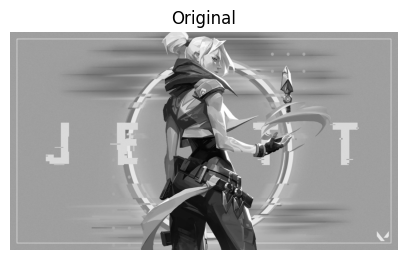

In [13]:
image = load_image(
    "../data/sample.jpg",
    grayscale=True
)

show_image(
    image,
    "Original"
)

In [14]:
conv_no_padding = Convolution2D(
    in_channels=1,
    out_channels=1,
    kernel_size=3,
    padding=0
)

feature_map = conv_no_padding.forward(
    image
)

print(
    "Output Shape:",
    feature_map.shape
)

Output Shape: (1, 1078, 1918)


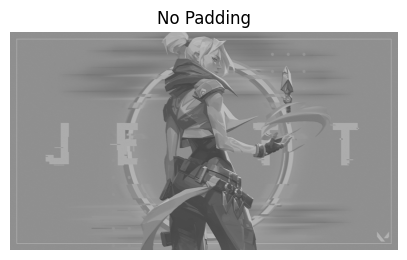

In [15]:
show_image(
    feature_map,
    "No Padding"
)

In [16]:
conv_padding = Convolution2D(
    in_channels=1,
    out_channels=1,
    kernel_size=3,
    padding=1
)

feature_map_pad = (
    conv_padding.forward(
        image
    )
)

print(
    "Output Shape:",
    feature_map_pad.shape
)

Output Shape: (1, 1080, 1920)


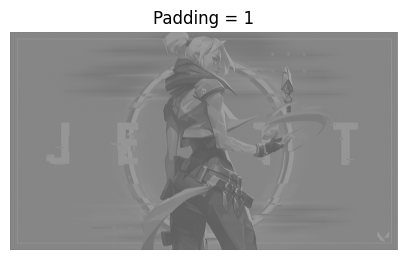

In [17]:
show_image(
    feature_map_pad,
    "Padding = 1"
)

In [18]:
print(
    "Input Shape:",
    image.shape
)

print(
    "Without Padding:",
    feature_map.shape
)

print(
    "With Padding:",
    feature_map_pad.shape
)

Input Shape: (1, 1080, 1920)
Without Padding: (1, 1078, 1918)
With Padding: (1, 1080, 1920)


Part 5 - Same Padding

In [19]:
print("""
Most modern CNNs use

Padding =
(Kernel Size - 1)/2

For 3x3 kernel:

Padding = 1

For 5x5 kernel:

Padding = 2

This keeps

Input Shape
=
Output Shape

when stride = 1
""")


Most modern CNNs use

Padding =
(Kernel Size - 1)/2

For 3x3 kernel:

Padding = 1

For 5x5 kernel:

Padding = 2

This keeps

Input Shape
=
Output Shape

when stride = 1



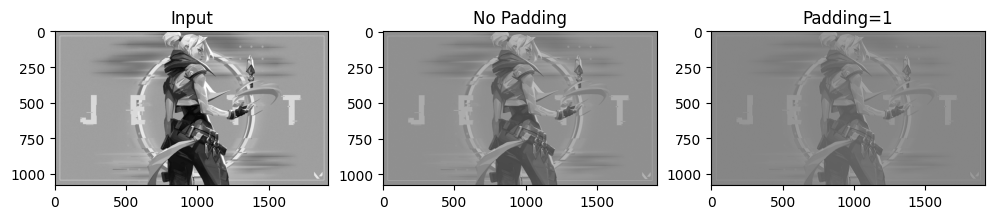

In [20]:
fig, ax = plt.subplots(
    1,
    3,
    figsize=(12,4)
)

ax[0].imshow(
    image[0],
    cmap="gray"
)

ax[0].set_title(
    "Input"
)

ax[1].imshow(
    feature_map[0],
    cmap="gray"
)

ax[1].set_title(
    "No Padding"
)

ax[2].imshow(
    feature_map_pad[0],
    cmap="gray"
)

ax[2].set_title(
    "Padding=1"
)

plt.show()